In [1]:
import pandas as pd

df = pd.read_csv("sales_data_sample.csv", encoding='latin1')
df.head()
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2823 entries, 0 to 2822
Data columns (total 25 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   ORDERNUMBER       2823 non-null   int64  
 1   QUANTITYORDERED   2823 non-null   int64  
 2   PRICEEACH         2823 non-null   float64
 3   ORDERLINENUMBER   2823 non-null   int64  
 4   SALES             2823 non-null   float64
 5   ORDERDATE         2823 non-null   object 
 6   STATUS            2823 non-null   object 
 7   QTR_ID            2823 non-null   int64  
 8   MONTH_ID          2823 non-null   int64  
 9   YEAR_ID           2823 non-null   int64  
 10  PRODUCTLINE       2823 non-null   object 
 11  MSRP              2823 non-null   int64  
 12  PRODUCTCODE       2823 non-null   object 
 13  CUSTOMERNAME      2823 non-null   object 
 14  PHONE             2823 non-null   object 
 15  ADDRESSLINE1      2823 non-null   object 
 16  ADDRESSLINE2      302 non-null    object 


In [2]:
df.drop_duplicates(inplace=True)
df.isnull().sum()

ORDERNUMBER            0
QUANTITYORDERED        0
PRICEEACH              0
ORDERLINENUMBER        0
SALES                  0
ORDERDATE              0
STATUS                 0
QTR_ID                 0
MONTH_ID               0
YEAR_ID                0
PRODUCTLINE            0
MSRP                   0
PRODUCTCODE            0
CUSTOMERNAME           0
PHONE                  0
ADDRESSLINE1           0
ADDRESSLINE2        2521
CITY                   0
STATE               1486
POSTALCODE            76
COUNTRY                0
TERRITORY           1074
CONTACTLASTNAME        0
CONTACTFIRSTNAME       0
DEALSIZE               0
dtype: int64

In [3]:
df['ORDERDATE'] = pd.to_datetime(df['ORDERDATE'])

In [4]:
df['year'] = df['ORDERDATE'].dt.year
df['month'] = df['ORDERDATE'].dt.month
df['day'] = df['ORDERDATE'].dt.dayofweek

<Axes: xlabel='ORDERDATE'>

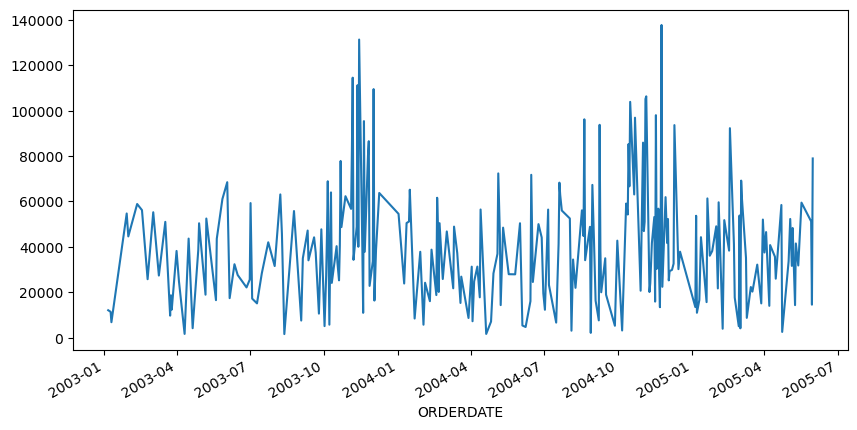

In [5]:
df.groupby('ORDERDATE')['SALES'].sum().plot(figsize=(10,5))

<Axes: ylabel='COUNTRY'>

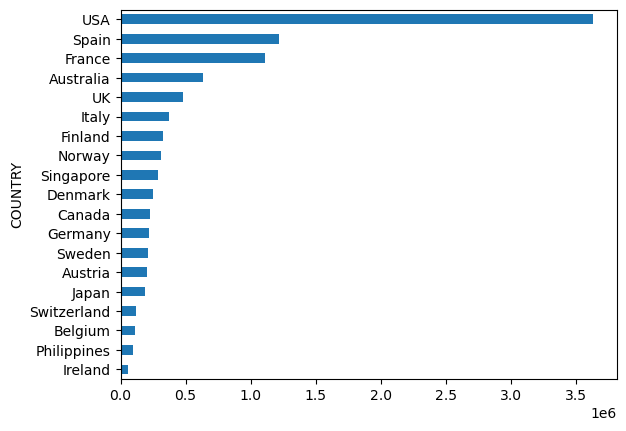

In [6]:
df.groupby('COUNTRY')['SALES'].sum().sort_values().plot(kind='barh')

<Axes: xlabel='PRODUCTLINE'>

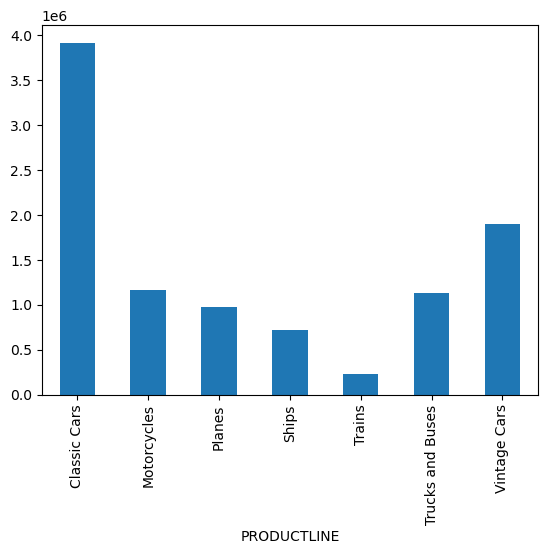

In [7]:
df.groupby('PRODUCTLINE')['SALES'].sum().plot(kind='bar')

In [8]:
rfm = df.groupby('CUSTOMERNAME').agg({
    'ORDERDATE': lambda x: (df['ORDERDATE'].max() - x.max()).days,
    'ORDERNUMBER': 'count',
    'SALES': 'sum'
})

rfm.columns = ['Recency', 'Frequency', 'Monetary']

In [9]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=3, random_state=42)
rfm['Cluster'] = kmeans.fit_predict(rfm)

C:\Users\lenovo\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


In [10]:
def label_cluster(row):
    if row['Cluster'] == 0:
        return "High Value"
    elif row['Cluster'] == 1:
        return "Medium"
    else:
        return "Low"

rfm['Segment'] = rfm.apply(label_cluster, axis=1)

In [11]:
from sklearn.model_selection import train_test_split

features = ['month', 'day']
X = df[features]
y = df['SALES']

X_train, X_test, y_train, y_test = train_test_split(X, y)

In [12]:
from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor()
model.fit(X_train, y_train)

RandomForestRegressor()

In [13]:
from sklearn.metrics import mean_squared_error

preds = model.predict(X_test)
import numpy as np
rmse = np.sqrt(mean_squared_error(y_test, preds))
print(rmse)

1802.2646956249848


In [15]:
import plotly.express as px
product_sales = df.groupby('PRODUCTLINE')['SALES'].sum().reset_index()

fig3 = px.pie(product_sales, 
              names='PRODUCTLINE', 
              values='SALES')

In [16]:
pip install dash plotly

Note: you may need to restart the kernel to use updated packages.


In [17]:
import dash
from dash import dcc, html
import plotly.express as px

app = dash.Dash(__name__)


colors = {
    "bg": "#0E1117",
    "card": "#161B22",
    "text": "#E6EDF3",
    "accent": "#4CC9F0"
}


fig1 = px.line(df, x='ORDERDATE', y='SALES',
               title="Sales Trend",
               template="plotly_dark",
               color_discrete_sequence=[colors["accent"]])

fig2 = px.bar(df, x='COUNTRY', y='SALES',
              title="Sales by Country",
              template="plotly_dark",
              color='COUNTRY',
              color_discrete_sequence=px.colors.qualitative.Set2)

product_sales = df.groupby('PRODUCTLINE')['SALES'].sum().reset_index()
fig3 = px.pie(product_sales, names='PRODUCTLINE', values='SALES',
              title="Product Share",
              template="plotly_dark",
              color_discrete_sequence=px.colors.qualitative.Set3)


app.layout = html.Div(style={'backgroundColor': colors["bg"], 'padding': '20px'}, children=[

    html.H1("📊 E-commerce Sales Dashboard",
            style={
                'textAlign': 'center',
                'color': colors["text"],
                'marginBottom': '30px'
            }),

    html.Div([
        dcc.Graph(figure=fig1),
    ], style={'backgroundColor': colors["card"], 'padding': '15px', 'borderRadius': '10px', 'marginBottom': '20px'}),

    html.Div([
        dcc.Graph(figure=fig2),
    ], style={'backgroundColor': colors["card"], 'padding': '15px', 'borderRadius': '10px', 'marginBottom': '20px'}),

    html.Div([
        dcc.Graph(figure=fig3),
    ], style={'backgroundColor': colors["card"], 'padding': '15px', 'borderRadius': '10px'}),

])

if __name__ == "__main__":
    app.run(debug=True)

In [18]:
import joblib
joblib.dump(model, "sales_model.pkl")
print("Model saved ")

Model saved 


In [19]:
model = joblib.load("sales_model.pkl")
print("Training columns:", model.feature_names_in_)
input_df = pd.DataFrame([[5, 2]], columns=model.feature_names_in_)
pred = model.predict(input_df)
print("Prediction:", pred)

Training columns: ['month' 'day']
Prediction: [3360.21484641]


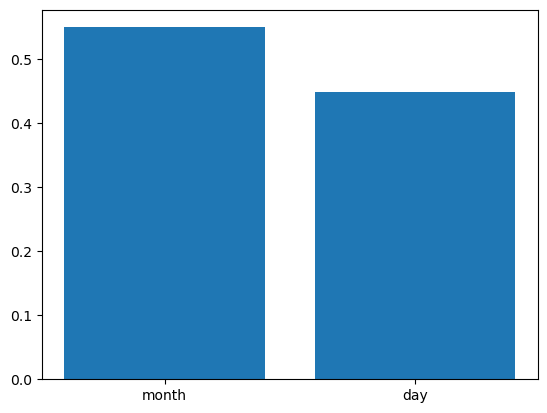

In [20]:
import matplotlib.pyplot as plt

features = model.feature_names_in_

plt.bar(features, model.feature_importances_)
plt.show()

In [21]:
from sklearn.linear_model import LinearRegression
import joblib
model = LinearRegression()
model.fit(X, y)
joblib.dump(model, "sales_model.pkl")

['sales_model.pkl']

In [24]:
import os
folder_path = r"C:\Users\lenovo\OneDrive\Desktop\Ecommerce_AI_Project" 
model_path = os.path.join(folder_path, "sales_model.pkl")
data = {
    "month": [1,2,3,4,5,6],
    "day": [5,10,15,20,25,30],
    "sales": [200,300,400,500,600,700]
}

df = pd.DataFrame(data)
X = df[["month", "day"]]
y = df["sales"]

model = LinearRegression()
model.fit(X, y)
joblib.dump(model, model_path)

print(f"✅ sales_model.pkl ban gaya folder me: {folder_path}")

✅ sales_model.pkl ban gaya folder me: C:\Users\lenovo\OneDrive\Desktop\Ecommerce_AI_Project
